# 화이트 와인 품질 예측 회귀 모델 - PyTorch

코드의 핵심 흐름은 다음과 같습니다.

1. `whitewines.csv` 데이터 읽기
2. 데이터 구조와 품질 점수 분포 확인
3. 훈련 데이터 75%, 테스트 데이터 25% 분리
4. 회귀 모델 학습
5. 예측값과 실제값 비교
6. 상관계수와 평균절대오차(MAE)로 성능 평가

여기서는 PyTorch의 신경망 회귀 모델로 변환합니다.


In [1]:
# ============================================================
# 1. 기본 라이브러리 불러오기
# ============================================================

# pandas는 표 형태의 데이터를 읽고 처리하기 위한 라이브러리입니다.
import pandas as pd

# numpy는 숫자 배열 계산을 빠르게 처리하기 위한 라이브러리입니다.
import numpy as np

# matplotlib은 그래프를 그리기 위한 라이브러리입니다.
import matplotlib.pyplot as plt

# torch는 PyTorch의 핵심 라이브러리입니다.
# 텐서 계산, 신경망 모델 생성, 학습 등에 사용합니다.
import torch

# torch.nn은 신경망의 층, 손실 함수 등을 만들 때 사용하는 모듈입니다.
import torch.nn as nn

# torch.optim은 모델의 가중치를 업데이트하는 최적화 알고리즘을 제공합니다.
import torch.optim as optim

# TensorDataset은 입력 데이터와 정답 데이터를 하나의 데이터셋으로 묶어 줍니다.
# DataLoader는 데이터를 미니배치 단위로 나누어 모델에 공급합니다.
from torch.utils.data import TensorDataset, DataLoader

# StandardScaler는 입력 특성의 단위를 표준화합니다.
# 평균은 0, 표준편차는 1이 되도록 바꿉니다.
from sklearn.preprocessing import StandardScaler

# mean_absolute_error는 평균절대오차 MAE를 계산합니다.
from sklearn.metrics import mean_absolute_error

# pearsonr은 실제값과 예측값 사이의 상관계수를 계산합니다.
from scipy.stats import pearsonr

# random은 파이썬 기본 난수 생성 라이브러리입니다.
import random

# 실행 결과가 매번 최대한 같게 나오도록 난수 시드를 고정합니다.
SEED = 123

# 파이썬 random 라이브러리의 난수 시드를 고정합니다.
random.seed(SEED)

# numpy의 난수 시드를 고정합니다.
np.random.seed(SEED)

# PyTorch의 CPU 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# GPU를 사용할 수 있으면 GPU(cuda)를 사용하고, 없으면 CPU를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 사용 중인 연산 장치를 출력합니다.
print("현재 사용 장치:", device)


현재 사용 장치: cuda


## 2. 데이터 불러오기

```
whitewines <- read.csv("data/whitewines.csv")
```

Colab에서는 로컬 파일이 없을 수 있으므로 UCI Machine Learning Repository의 White Wine Quality 데이터를 직접 내려받습니다.
만약 직접 `whitewines.csv` 파일을 업로드해서 사용하려면 아래 코드의 `DATA_URL` 대신 업로드 파일 경로를 사용하면 됩니다.


In [2]:
# ============================================================
# 2. 화이트 와인 데이터 불러오기
# ============================================================

# 다음 실행 때도 같은 파일을 사용할 수 있도록 data 폴더에 저장합니다.
import os
local_path = "data/winequality-white.csv"

# data 폴더가 없으면 새로 생성합니다.
os.makedirs("data", exist_ok=True)


# UCI에서 제공하는 화이트 와인 품질 데이터 CSV 파일 주소입니다.
# 이 데이터는 세미콜론(;)으로 컬럼이 구분되어 있습니다.
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# local_path 파일이 실제로 존재하는지 확인합니다.
if os.path.exists(local_path):
    # 파일이 있으면 사용자가 제공한 로컬 CSV 파일을 읽습니다.
    whitewines = pd.read_csv(local_path)
else:
    # pandas의 read_csv() 함수로 CSV 파일을 읽습니다.
    # sep=';'는 컬럼 구분자가 쉼표가 아니라 세미콜론이라는 뜻입니다.
    whitewines = pd.read_csv(DATA_URL, sep=';')
    
    # 다음 실행 때도 같은 파일을 사용할 수 있도록 data 폴더에 저장합니다.
    whitewines.to_csv(local_path, index=False)

# UCI 원본 데이터는 volatile acidity처럼 공백을 포함하므로,
# 초보자가 다루기 쉽게 공백을 밑줄(_)로 바꿉니다.
whitewines.columns = [col.replace(" ", "_") for col in whitewines.columns]

# 데이터의 앞 5행을 출력하여 제대로 읽혔는지 확인합니다.
whitewines.head()


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
# ============================================================
# 3. 데이터 기본 정보 확인
# ============================================================

# 데이터의 행 개수와 열 개수를 출력합니다.
print("데이터 크기:", whitewines.shape)

# 각 컬럼 이름과 데이터 타입을 확인합니다.
print("\n데이터 정보:")
whitewines.info()

# 숫자형 데이터의 기본 통계량을 확인합니다.
whitewines.describe()


데이터 크기: (4898, 12)

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         4898 non-null   float64
 1   volatile_acidity      4898 non-null   float64
 2   citric_acid           4898 non-null   float64
 3   residual_sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free_sulfur_dioxide   4898 non-null   float64
 6   total_sulfur_dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


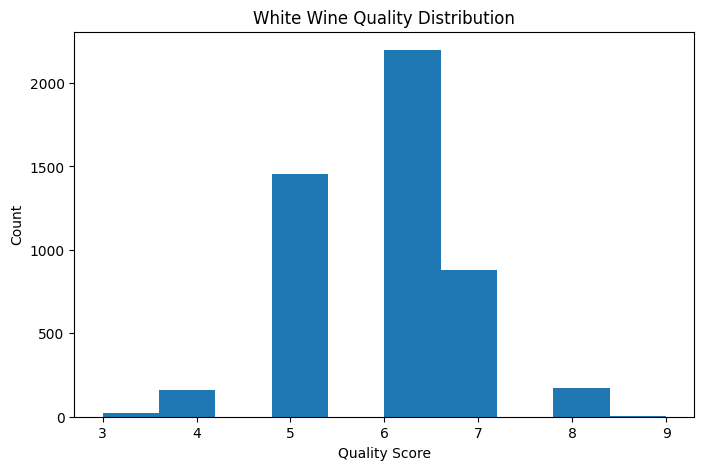

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


In [4]:
# ============================================================
# 4. 품질 점수 분포 확인
# ============================================================

# quality 컬럼은 와인의 품질 점수입니다.
# 점수는 보통 0~10 범위로 설명되지만 실제 데이터에서는 주로 3~9 사이 값이 많습니다.

# 히스토그램을 그려 품질 점수가 어떻게 분포되어 있는지 확인합니다.
plt.figure(figsize=(8, 5))

# bins는 막대 구간 수를 의미합니다.
plt.hist(whitewines["quality"], bins=10)

# 그래프 제목을 설정합니다.
plt.title("White Wine Quality Distribution")

# x축 이름을 설정합니다.
plt.xlabel("Quality Score")

# y축 이름을 설정합니다.
plt.ylabel("Count")

# 그래프를 화면에 표시합니다.
plt.show()

# 품질 점수별 데이터 개수를 출력합니다.
print(whitewines["quality"].value_counts().sort_index())


## 5. 입력 데이터와 정답 데이터 분리

머신러닝에서는 보통 다음처럼 데이터를 나눕니다.

- `X`: 입력 데이터, 즉 모델이 보고 학습할 특성
- `y`: 정답 데이터, 즉 모델이 맞혀야 하는 값

여기서는 와인의 화학 속성들이 `X`, 와인 품질 점수 `quality`가 `y`입니다.


In [5]:
# ============================================================
# 5. 입력 X와 정답 y 분리
# ============================================================

# quality 컬럼은 예측해야 할 정답이므로 입력 데이터에서 제거합니다.
X = whitewines.drop("quality", axis=1)

# quality 컬럼만 따로 분리하여 정답 데이터로 사용합니다.
y = whitewines["quality"]

# 입력 데이터의 컬럼 이름을 확인합니다.
print("입력 특성 목록:")
print(X.columns.tolist())

# 입력 데이터 크기를 확인합니다.
print("\nX 크기:", X.shape)

# 정답 데이터 크기를 확인합니다.
print("y 크기:", y.shape)


입력 특성 목록:
['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']

X 크기: (4898, 11)
y 크기: (4898,)


## 6. 훈련 데이터와 테스트 데이터 분리

```
whitewines_train <- whitewines[1:3749, ]
whitewines_test <- whitewines[3750:4898, ]
```

앞쪽 3749개를 훈련 데이터로, 나머지 1149개를 테스트 데이터로 사용합니다.


In [6]:
# ============================================================
# 6. 훈련 데이터와 테스트 데이터 분리
# ============================================================

# 0번부터 3748번까지 총 3749개를 훈련용으로 사용합니다.
X_train = X.iloc[:3749].copy()

# 3749번부터 마지막까지 총 1149개를 테스트용으로 사용합니다.
X_test = X.iloc[3749:].copy()

# 정답 데이터도 같은 기준으로 나눕니다.
y_train = y.iloc[:3749].copy()

# 테스트 정답 데이터도 같은 기준으로 나눕니다.
y_test = y.iloc[3749:].copy()

# 훈련 데이터와 테스트 데이터의 크기를 출력합니다.
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (3749, 11)
X_test : (1149, 11)
y_train: (3749,)
y_test : (1149,)


## 7. 데이터 표준화

신경망 모델은 입력 값의 크기 차이가 너무 크면 학습이 불안정해질 수 있습니다.

예를 들어,

- `alcohol`: 약 8~14
- `free_sulfur_dioxide`: 수십 단위
- `total_sulfur_dioxide`: 수백 단위

처럼 특성마다 값의 범위가 다릅니다.  
따라서 평균 0, 표준편차 1이 되도록 변환합니다.


In [7]:
# ============================================================
# 7. 입력 특성 표준화
# ============================================================

# StandardScaler 객체를 생성합니다.
scaler = StandardScaler()

# 훈련 데이터의 평균과 표준편차를 계산하고, 그 기준으로 훈련 데이터를 변환합니다.
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터는 훈련 데이터에서 계산한 평균과 표준편차로만 변환합니다.
# 테스트 데이터 기준으로 다시 fit하면 실제 평가가 왜곡될 수 있습니다.
X_test_scaled = scaler.transform(X_test)

# 표준화된 훈련 데이터의 평균이 0에 가까운지 간단히 확인합니다.
print("표준화 후 훈련 데이터 평균:", X_train_scaled.mean().round(4))

# 표준화된 훈련 데이터의 표준편차가 1에 가까운지 간단히 확인합니다.
print("표준화 후 훈련 데이터 표준편차:", X_train_scaled.std().round(4))


표준화 후 훈련 데이터 평균: 0.0
표준화 후 훈련 데이터 표준편차: 1.0


## 8. NumPy 배열을 PyTorch 텐서로 변환

PyTorch 모델은 `pandas DataFrame`을 직접 학습하지 않습니다.  
모델 학습을 위해 데이터를 `torch.Tensor` 형태로 변환해야 합니다.


In [8]:
# ============================================================
# 8. PyTorch 텐서로 변환
# ============================================================

# 입력 데이터 X_train_scaled를 float32 타입의 PyTorch 텐서로 변환합니다.
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)

# 테스트 입력 데이터도 float32 텐서로 변환합니다.
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# 정답 데이터 y_train은 1차원 Series이므로 values로 배열을 꺼냅니다.
# view(-1, 1)은 (데이터개수,) 형태를 (데이터개수, 1) 형태로 바꿉니다.
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

# 테스트 정답 데이터도 같은 방식으로 텐서로 변환합니다.
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# 변환된 텐서의 크기를 확인합니다.
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor :", X_test_tensor.shape)
print("y_test_tensor :", y_test_tensor.shape)


X_train_tensor: torch.Size([3749, 11])
y_train_tensor: torch.Size([3749, 1])
X_test_tensor : torch.Size([1149, 11])
y_test_tensor : torch.Size([1149, 1])


In [9]:
# ============================================================
# 9. DataLoader 생성
# ============================================================

# TensorDataset은 입력 데이터와 정답 데이터를 하나의 묶음으로 만듭니다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# batch_size는 한 번에 모델에 넣을 데이터 개수입니다.
# 예를 들어 batch_size=64이면 64개씩 나누어 학습합니다.
BATCH_SIZE = 64

# DataLoader는 데이터를 batch_size 단위로 나누어 반복해서 꺼내 줍니다.
# shuffle=True는 매 epoch마다 데이터 순서를 섞겠다는 의미입니다.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# DataLoader가 몇 개의 미니배치를 만드는지 확인합니다.
print("미니배치 개수:", len(train_loader))


미니배치 개수: 59


## 10. PyTorch 회귀 모델 정의

회귀 문제는 숫자 값을 예측하는 문제입니다.

여기서는 와인 품질 점수라는 하나의 숫자를 예측합니다.

모델 구조:

```text
입력층: 11개 특성
은닉층1: 64개 뉴런
은닉층2: 32개 뉴런
출력층: 1개 값
```


In [10]:
# ============================================================
# 10. PyTorch 회귀 모델 정의
# ============================================================

# nn.Module은 PyTorch에서 모든 신경망 모델의 기본 클래스입니다.
class WineQualityRegressor(nn.Module):

    # __init__()은 모델 안에 사용할 층을 정의하는 함수입니다.
    def __init__(self, input_dim):

        # 부모 클래스 nn.Module의 초기화 기능을 실행합니다.
        super(WineQualityRegressor, self).__init__()

        # self.network는 여러 층을 순서대로 연결한 신경망입니다.
        self.network = nn.Sequential(

            # 첫 번째 선형층입니다.
            # input_dim은 입력 특성 개수이고, 64는 출력 뉴런 개수입니다.
            nn.Linear(input_dim, 64),

            # ReLU는 음수는 0으로 바꾸고 양수는 그대로 통과시키는 활성화 함수입니다.
            nn.ReLU(),

            # Dropout은 일부 뉴런을 임시로 꺼서 과적합을 줄이는 방법입니다.
            nn.Dropout(0.2),

            # 두 번째 선형층입니다.
            # 앞 층의 출력 64개를 받아 32개로 줄입니다.
            nn.Linear(64, 32),

            # 두 번째 활성화 함수입니다.
            nn.ReLU(),

            # 최종 출력층입니다.
            # 회귀 문제이므로 최종 출력은 품질 점수 1개입니다.
            nn.Linear(32, 1)
        )

    # forward()는 입력 데이터가 모델을 통과하는 순서를 정의합니다.
    def forward(self, x):

        # 입력 x를 self.network에 넣고 결과를 반환합니다.
        return self.network(x)


# 입력 특성 개수는 X_train_tensor의 열 개수입니다.
input_dim = X_train_tensor.shape[1]

# 모델 객체를 생성합니다.
model = WineQualityRegressor(input_dim)

# 모델을 CPU 또는 GPU 장치로 이동합니다.
model = model.to(device)

# 모델 구조를 출력합니다.
print(model)


WineQualityRegressor(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 11. 손실 함수와 최적화 알고리즘 설정

회귀 문제에서는 예측값과 실제값의 차이를 줄이는 방향으로 학습합니다.

여기서는 다음을 사용합니다.

- 손실 함수: `MSELoss`
- 최적화 알고리즘: `Adam`


In [11]:
# ============================================================
# 11. 손실 함수와 최적화 알고리즘 설정
# ============================================================

# MSELoss는 평균제곱오차입니다.
# 예측값과 실제값의 차이를 제곱한 뒤 평균을 냅니다.
criterion = nn.MSELoss()

# Adam은 많이 사용되는 최적화 알고리즘입니다.
# 모델의 가중치를 조금씩 수정하여 손실을 줄입니다.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 반복 횟수입니다.
# epoch는 전체 훈련 데이터를 한 번 모두 학습하는 단위입니다.
EPOCHS = 200


In [12]:
# ============================================================
# 12. 모델 학습
# ============================================================

# epoch별 평균 손실을 저장할 리스트입니다.
train_losses = []

# 지정한 epoch 수만큼 반복합니다.
for epoch in range(EPOCHS):

    # model.train()은 모델을 학습 모드로 설정합니다.
    # Dropout 같은 층은 학습 모드와 평가 모드에서 동작이 다릅니다.
    model.train()

    # 한 epoch 동안의 손실 합계를 저장할 변수입니다.
    epoch_loss = 0.0

    # train_loader에서 미니배치 단위로 데이터를 꺼냅니다.
    for batch_X, batch_y in train_loader:

        # 입력 데이터 batch_X를 CPU 또는 GPU 장치로 이동합니다.
        batch_X = batch_X.to(device)

        # 정답 데이터 batch_y도 같은 장치로 이동합니다.
        batch_y = batch_y.to(device)

        # 이전 미니배치에서 계산된 기울기를 초기화합니다.
        optimizer.zero_grad()

        # 모델에 입력 데이터를 넣어 예측값을 계산합니다.
        predictions = model(batch_X)

        # 예측값과 실제값의 차이를 손실 함수로 계산합니다.
        loss = criterion(predictions, batch_y)

        # 손실을 기준으로 각 가중치의 기울기를 계산합니다.
        loss.backward()

        # 계산된 기울기를 이용해 모델 가중치를 업데이트합니다.
        optimizer.step()

        # 현재 미니배치 손실에 데이터 개수를 곱해 누적합니다.
        epoch_loss += loss.item() * batch_X.size(0)

    # 전체 데이터 개수로 나누어 한 epoch의 평균 손실을 계산합니다.
    epoch_loss = epoch_loss / len(train_loader.dataset)

    # 계산된 평균 손실을 리스트에 저장합니다.
    train_losses.append(epoch_loss)

    # 20 epoch마다 학습 진행 상황을 출력합니다.
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.4f}")


Epoch [ 20/200] - Train MSE Loss: 0.7825
Epoch [ 40/200] - Train MSE Loss: 0.5926
Epoch [ 60/200] - Train MSE Loss: 0.5329
Epoch [ 80/200] - Train MSE Loss: 0.5134
Epoch [100/200] - Train MSE Loss: 0.5054
Epoch [120/200] - Train MSE Loss: 0.4854
Epoch [140/200] - Train MSE Loss: 0.4808
Epoch [160/200] - Train MSE Loss: 0.4648
Epoch [180/200] - Train MSE Loss: 0.4511
Epoch [200/200] - Train MSE Loss: 0.4444


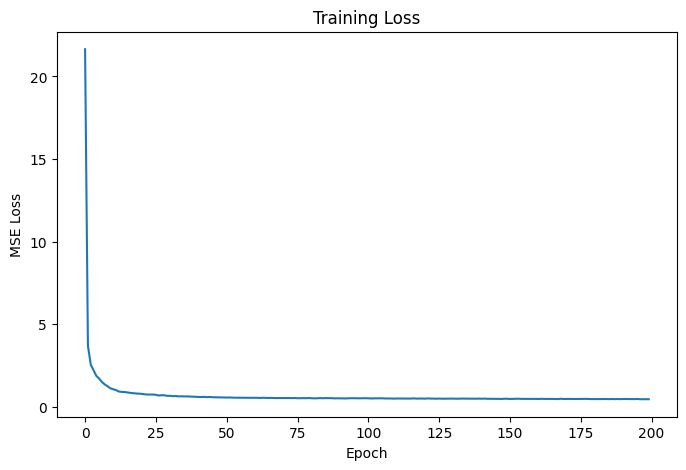

In [13]:
# ============================================================
# 13. 학습 손실 그래프 출력
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# epoch별 손실 값을 선 그래프로 표시합니다.
plt.plot(train_losses)

# 그래프 제목을 설정합니다.
plt.title("Training Loss")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("MSE Loss")

# 그래프를 화면에 표시합니다.
plt.show()


## 14. 테스트 데이터 예측

학습이 끝난 모델을 테스트 데이터에 적용합니다.  



In [14]:
# ============================================================
# 14. 테스트 데이터 예측
# ============================================================

# model.eval()은 모델을 평가 모드로 설정합니다.
# Dropout이 꺼지고, 평가에 적합한 방식으로 동작합니다.
model.eval()

# torch.no_grad()는 예측 중에는 기울기를 계산하지 않겠다는 의미입니다.
# 평가 시에는 가중치를 업데이트하지 않으므로 메모리를 절약할 수 있습니다.
with torch.no_grad():

    # 테스트 입력 데이터를 CPU 또는 GPU 장치로 이동합니다.
    X_test_device = X_test_tensor.to(device)

    # 모델을 이용하여 테스트 데이터의 품질 점수를 예측합니다.
    test_predictions = model(X_test_device)

    # 예측 결과를 CPU로 가져오고 numpy 배열로 변환합니다.
    test_predictions = test_predictions.cpu().numpy().flatten()

# 실제 정답도 numpy 배열로 변환합니다.
actual_values = y_test.values

# 예측값 앞 10개를 출력합니다.
print("예측값 앞 10개:")
print(test_predictions[:10])

# 실제값 앞 10개를 출력합니다.
print("\n실제값 앞 10개:")
print(actual_values[:10])


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
예측값 앞 10개:
[6.4679055 6.5665455 5.9003234 5.739285  5.730684  7.3376513 7.103829
 5.9003234 5.739285  5.730684 ]

실제값 앞 10개:
[6 7 5 5 5 8 6 5 5 5]


In [15]:
# ============================================================
# 15. 예측값과 실제값의 요약 통계 비교
# ============================================================

# 예측값을 pandas Series로 변환하여 describe()를 사용할 수 있게 합니다.
pred_series = pd.Series(test_predictions, name="predicted_quality")

# 실제값도 pandas Series로 준비합니다.
actual_series = pd.Series(actual_values, name="actual_quality")

# 예측값의 요약 통계를 출력합니다.
print("예측값 요약 통계:")
print(pred_series.describe())

# 실제값의 요약 통계를 출력합니다.
print("\n실제값 요약 통계:")
print(actual_series.describe())


예측값 요약 통계:
count    1149.000000
mean        6.055666
std         0.614786
min         0.677071
25%         5.622684
50%         6.102898
75%         6.504328
max         7.781892
Name: predicted_quality, dtype: float64

실제값 요약 통계:
count    1149.000000
mean        5.848564
std         0.780674
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: actual_quality, dtype: float64


In [16]:
# ============================================================
# 16. 모델 성능 평가: 상관계수와 MAE
# ============================================================

# pearsonr()은 두 숫자 배열 사이의 상관계수를 계산합니다.
# 상관계수는 -1부터 1까지이며, 1에 가까울수록 양의 관계가 강합니다.
correlation, p_value = pearsonr(test_predictions, actual_values)

# mean_absolute_error()는 평균절대오차 MAE를 계산합니다.
# MAE는 실제값과 예측값의 차이를 절댓값으로 바꾼 뒤 평균을 낸 값입니다.
mae = mean_absolute_error(actual_values, test_predictions)

# 훈련 데이터 품질 점수의 평균을 계산합니다.
train_mean_quality = y_train.mean()

# 모든 테스트 데이터를 평균값 하나로 예측한다고 가정한 기준 모델의 MAE입니다.
baseline_predictions = np.full_like(actual_values, fill_value=train_mean_quality, dtype=np.float32)

# 기준 모델의 MAE를 계산합니다.
baseline_mae = mean_absolute_error(actual_values, baseline_predictions)

# 결과를 출력합니다.
print(f"PyTorch 모델 상관계수: {correlation:.4f}")
print(f"PyTorch 모델 MAE     : {mae:.4f}")
print(f"훈련 데이터 평균값    : {train_mean_quality:.4f}")
print(f"평균값 기준 MAE       : {baseline_mae:.4f}")


PyTorch 모델 상관계수: 0.6144
PyTorch 모델 MAE     : 0.5376
훈련 데이터 평균값    : 5.8869
평균값 기준 MAE       : 0.5749


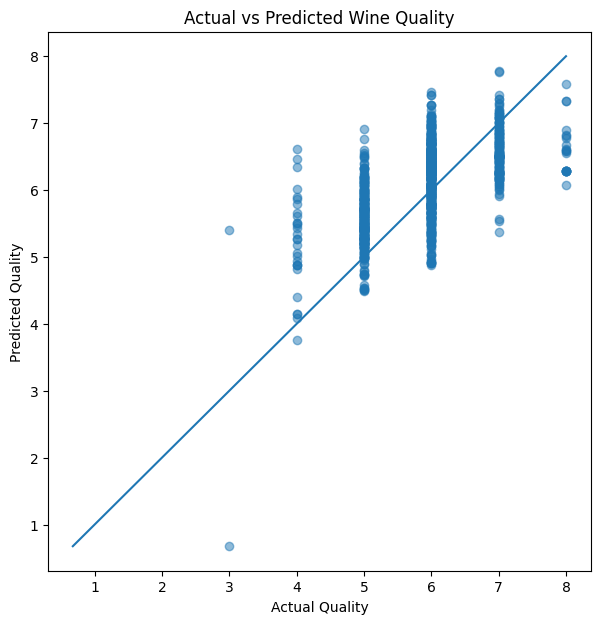

In [17]:
# ============================================================
# 17. 예측값과 실제값 산점도 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(7, 7))

# 실제값과 예측값을 산점도로 표시합니다.
plt.scatter(actual_values, test_predictions, alpha=0.5)

# x축 이름을 설정합니다.
plt.xlabel("Actual Quality")

# y축 이름을 설정합니다.
plt.ylabel("Predicted Quality")

# 그래프 제목을 설정합니다.
plt.title("Actual vs Predicted Wine Quality")

# 실제값과 예측값이 완전히 같을 때의 기준선을 그립니다.
min_value = min(actual_values.min(), test_predictions.min())
max_value = max(actual_values.max(), test_predictions.max())
plt.plot([min_value, max_value], [min_value, max_value])

# 그래프를 화면에 표시합니다.
plt.show()


In [18]:
# ============================================================
# 18. 예측 결과 일부 확인
# ============================================================

# 실제값과 예측값을 하나의 DataFrame으로 정리합니다.
result_df = pd.DataFrame({
    "actual_quality": actual_values,
    "predicted_quality": test_predictions,
})

# 예측 오차를 계산합니다.
result_df["error"] = result_df["actual_quality"] - result_df["predicted_quality"]

# 절대 오차를 계산합니다.
result_df["absolute_error"] = result_df["error"].abs()

# 결과 앞 20개를 확인합니다.
result_df.head(20)


,actual_quality,predicted_quality,error,absolute_error
0,6,6.467906,-0.467906,0.467906
1,7,6.566545,0.433455,0.433455
2,5,5.900323,-0.900323,0.900323
3,5,5.739285,-0.739285,0.739285
4,5,5.730684,-0.730684,0.730684
5,8,7.337651,0.662349,0.662349
6,6,7.103829,-1.103829,1.103829
7,5,5.900323,-0.900323,0.900323
8,5,5.739285,-0.739285,0.739285
9,5,5.730684,-0.730684,0.730684


In [19]:
# ============================================================
# 19. 사용자 정의 MAE 함수 작성
# ============================================================

# WMAE라는 평균절대오차 계산 함수 구현
def WMAE(actual, predict):

    # actual과 predict를 numpy 배열로 변환합니다.
    actual = np.array(actual)
    predict = np.array(predict)

    # 실제값과 예측값의 차이를 절댓값으로 바꾼 뒤 평균을 계산합니다.
    return np.mean(np.abs(actual - predict))


# 사용자 정의 함수로 MAE를 다시 계산합니다.
print("WMAE 함수로 계산한 MAE:", WMAE(actual_values, test_predictions))


WMAE 함수로 계산한 MAE: 0.5376213938905635
